# Построение графа и извлечение признаков

Ядро графового эксперимента: семантические рёбра между сообщениями, признаки без GNN, сохранение в `artifacts/`.

См. также [`../README.md`](../README.md).

In [94]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
ART_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)
# === paths ===
DATA_DIR = str(ROOT / "data")          # поменяй под себя
ART_DIR  = str(ROOT / "artifacts")
import os
os.makedirs(ART_DIR, exist_ok=True)

MESSAGES_PATH = os.path.join(DATA_DIR, "messages_with_reactions.csv")
TARGETS_PATH  = os.path.join(DATA_DIR, "message_targets.csv")

# если у тебя уже есть train/val/test:
TRAIN_PATH = os.path.join(DATA_DIR, "train_ids.csv")
VAL_PATH   = os.path.join(DATA_DIR, "valid_ids.csv")
TEST_PATH  = os.path.join(DATA_DIR, "test_ids.csv")

# === imports ===
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta

# sparse + svd
from scipy import sparse
from sklearn.feature_extraction import DictVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# knn/ann
from sklearn.neighbors import NearestNeighbors

# metrics & model
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve

import lightgbm as lgb
import networkx as nx


## Определение схемы графа

In [142]:
schema_md = """# Graph schema (Stage 6)

## Nodes
- **Channel**: id_channel
- **Message**: id (uuid)

## Edges
1) **Channel → Message**
- name: `publishes`
- direction: Channel -> Message
- attributes:
  - `t` : message publish timestamp (`date`)
  - `message_id` (optional)

2) **Message ↔ Message**
- name: `similar`
- direction: undirected (store as two directed or a single undirected table)
- condition:
  - cosine(sim(message_vec_i, message_vec_j)) > θ
  - |date_i - date_j| ≤ 24h
- attributes:
  - `t_src` : publish time of src message
  - `t_dst` : publish time of dst message
  - `cosine` : similarity value

## Notes (leakage-safe)
- Graph is built using **content vectors** and **timestamps only**.
- Feature "share of neighbors with historical viral" uses only neighbors with publish time < current message time.
"""
with open(os.path.join(ART_DIR, "graph_schema.md"), "w", encoding="utf-8") as f:
    f.write(schema_md)

print("Saved:", os.path.join(ART_DIR, "graph_schema.md"))

Saved: ./artifacts\graph_schema.md


In [3]:
messages = pd.concat(dfs)

In [4]:
messages.head()

,id,date,id_channel,message_vector,cur_date
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,2025-01-02 17:00:02+00:00,3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,2025-01-02 00:00:00+00:00
1,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,2025-01-02 17:00:02+00:00,3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,2025-01-23 00:00:00+00:00
2,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,2025-01-02 17:00:02+00:00,3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,2025-01-24 00:00:00+00:00
3,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,2025-01-02 17:00:02+00:00,3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,2025-01-25 00:00:00+00:00
4,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,2025-01-02 17:00:02+00:00,3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,2025-01-26 00:00:00+00:00


In [5]:
targets = pd.read_csv(TARGETS_PATH)

In [6]:
messages["date"] = pd.to_datetime(messages["date"], utc=True, errors="coerce")
targets["date"]  = pd.to_datetime(targets["date"],  utc=True, errors="coerce")

In [7]:
msgs = messages.drop_duplicates('id').copy()
msgs['date'] = pd.to_datetime(msgs['date'])

In [8]:
targets.head()

,id,views_h24,views_h48,forwards_h24,forwards_h48,reactions_h24,reactions_h48,date,week,q90_forwards_h24,viral
0,00027151-a524-4d93-a820-116398fb81bb,1095396.0,619397.0,796.0,449.0,0.0,0.0,2025-04-07 11:53:51+00:00,2025-04-07/2025-04-13,2558.0,0
1,0002bd57-00d6-4d1d-b9cf-7a16ea0a0346,29631.0,30447.0,108.0,111.0,752.0,6.0,2025-01-21 16:26:30+00:00,2025-01-20/2025-01-26,2710.8,0
2,0003b835-cf4a-43ff-b155-a144cf56b7f8,486195.0,507393.0,273.0,273.0,0.0,0.0,2025-07-29 20:55:09+00:00,2025-07-28/2025-08-03,3205.2,0
3,00042e3e-de7f-4172-b553-a55477d04f93,1032474.0,600872.0,930.0,500.0,0.0,0.0,2025-04-08 12:25:06+00:00,2025-04-07/2025-04-13,2558.0,0
4,0005535a-74a9-4cb9-853f-ce04612d2f94,1065435.0,627631.0,999.0,551.0,0.0,0.0,2025-04-01 13:53:43+00:00,2025-03-31/2025-04-06,2946.4,0


In [9]:


# подцепим вирусность и forwards_h24 (нужно для "historical viral share")
msg = msgs.merge(targets[["id", "forwards_h24", "viral", "date"]].rename(columns={"date":"publish_date"}),
                       on="id", how="left")

# publish_date возьмем из messages.date, если в targets по какой-то причине пусто
msg["publish_date"] = msg["publish_date"].fillna(msg["date"])

msg[["id","id_channel","publish_date"]].head()

,id,id_channel,publish_date
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,3,2025-01-02 17:00:02+00:00
1,792632e5-da04-4341-a674-f8405c8ddd71,3,2025-01-02 16:40:53+00:00
2,dcb05245-5965-4003-81a5-421043394def,3,2025-01-02 16:20:12+00:00
3,e91db7c4-d272-4b0b-82f9-425016288476,3,2025-01-02 15:54:29+00:00
4,c702e716-6806-497b-83ba-764eee4f82e3,3,2025-01-02 15:32:55+00:00


## Построение рёбер

In [10]:
_token_re = re.compile(r"'([^']+)':([0-9]+(?:\.[0-9]+)?)")

def parse_message_vector(s: str) -> dict:
    if not isinstance(s, str) or len(s) == 0:
        return {}
    d = {}
    for tok, val in _token_re.findall(s):
        d[tok] = float(val)
    return d

# парсим в список dict
vec_dicts = msg["message_vector"].apply(parse_message_vector).tolist()

# sparse bag-of-words
dv = DictVectorizer(sparse=True)
X = dv.fit_transform(vec_dicts)  # (n_messages, vocab_size)

# SVD (размер подбери, но 128-256 обычно ок)
SVD_DIM = 128
svd = TruncatedSVD(n_components=SVD_DIM, random_state=42)
X_svd = svd.fit_transform(X).astype(np.float32)

# нормируем для cosine (тогда dot = cosine)
norms = np.linalg.norm(X_svd, axis=1, keepdims=True) + 1e-12
X_svd_norm = X_svd / norms

print("X_svd_norm:", X_svd_norm.shape)


X_svd_norm: (123273, 128)


In [14]:
edges_ch_msg = msg[["id_channel", "id", "publish_date"]].copy()
edges_ch_msg = edges_ch_msg.rename(columns={"id_channel":"src", "id":"dst", "publish_date":"t"})
# типы узлов полезно хранить явно
edges_ch_msg["src_type"] = "channel"
edges_ch_msg["dst_type"] = "message"
edges_ch_msg["edge_type"] = "publishes"

# parquet
edges_ch_msg_path = os.path.join(ART_DIR, "edges_ch_msg.csv")
edges_ch_msg.to_csv(edges_ch_msg_path, index=False)
print("Saved:", edges_ch_msg_path, "rows=", len(edges_ch_msg))


Saved: ./artifacts\edges_ch_msg.csv rows= 123273


In [15]:
THETA = 0.55      # порог cosine, подбери (0.45–0.75 часто разумно)
TOPK  = 50        # сколько соседей смотреть на сообщение (до фильтра θ/времени)

times = msg["publish_date"].values.astype("datetime64[ns]")
n = len(msg)

# NearestNeighbors с cosine distance = 1 - cosine
# Мы используем нормированные векторы, но metric='cosine' и так норм.
nn = NearestNeighbors(n_neighbors=TOPK+1, metric="cosine", algorithm="brute", n_jobs=-1)
nn.fit(X_svd_norm)

dist, ind = nn.kneighbors(X_svd_norm, return_distance=True)

# dist shape (n, TOPK+1), первый сосед = сам объект (dist=0)
rows = []
max_dt = np.timedelta64(24, "h")

for i in range(n):
    t_i = times[i]
    for jpos in range(1, TOPK+1):
        j = ind[i, jpos]
        # cosine similarity:
        cos = 1.0 - dist[i, jpos]
        if cos < THETA:
            continue
        # time window
        if np.abs(times[j] - t_i) > max_dt:
            continue
        rows.append((msg.loc[i, "id"], msg.loc[j, "id"], msg.loc[i, "publish_date"], msg.loc[j, "publish_date"], float(cos)))

edges_msg_msg = pd.DataFrame(rows, columns=["src","dst","t_src","t_dst","cosine"])

# убираем дубли (i->j и j->i могут присутствовать) и self-loops на всякий случай
edges_msg_msg = edges_msg_msg[edges_msg_msg["src"] != edges_msg_msg["dst"]].copy()

# если хочешь хранить как неориентированный: упорядочим пару
a = edges_msg_msg["src"].astype(str).values
b = edges_msg_msg["dst"].astype(str).values
min_ab = np.minimum(a, b)
max_ab = np.maximum(a, b)
edges_msg_msg["u"] = min_ab
edges_msg_msg["v"] = max_ab

edges_msg_msg_und = (
    edges_msg_msg
    .sort_values("cosine", ascending=False)
    .drop_duplicates(["u","v"], keep="first")
    .drop(columns=["u","v"])
    .reset_index(drop=True)
)

edges_msg_msg_und["edge_type"] = "similar"
edges_msg_msg_und["src_type"] = "message"
edges_msg_msg_und["dst_type"] = "message"


In [17]:
edges_msg_msg_und

,src,dst,t_src,t_dst,cosine,edge_type,src_type,dst_type
0,c2944fb3-77de-4c24-a077-cff320306dfc,de792a4a-6dec-40a7-89e3-b3d307e55f6c,2025-01-02 08:06:12+00:00,2025-01-02 08:08:09+00:00,1.000000,similar,message,message
1,46049331-b278-421b-a370-540f0139cdd2,35c8f416-7f5a-44bc-8809-ece6fa78042e,2024-12-08 09:04:13+00:00,2024-12-08 08:47:48+00:00,1.000000,similar,message,message
2,fe7bd5c8-a8a4-4c75-a0ca-c0396fa8e5c8,6b2b1e33-7abb-47d5-9044-73243ea81e4c,2025-04-28 11:56:34+00:00,2025-04-28 11:48:42+00:00,1.000000,similar,message,message
3,6fa87118-c085-4734-823d-d7f45ba3ddfe,5f7cde37-2938-43fe-b4ca-709c1db01be9,2024-08-30 13:22:21+00:00,2024-08-30 13:22:21+00:00,1.000000,similar,message,message
4,bef5a97a-2eae-4e18-9aa0-ccc806f01ae9,b22b9623-b63d-4a37-b3a1-04317504727f,2024-12-05 10:36:31+00:00,2024-12-05 10:36:02+00:00,1.000000,similar,message,message
...,...,...,...,...,...,...,...,...
85979,3552ae52-06f1-4755-b0af-945d1bae6c54,b5d24bb4-0349-4df3-b503-628e4595cbd0,2025-05-12 11:12:53+00:00,2025-05-13 09:40:06+00:00,0.550054,similar,message,message
85980,f067cdfb-76f8-405f-9956-5d2214237aac,5516e594-6cda-478b-8aca-a67047712b85,2024-05-27 05:15:30+00:00,2024-05-27 21:35:31+00:00,0.550052,similar,message,message
85981,e273d760-25da-4bde-8b65-784f7e44930c,e984ae1f-6e7a-4965-94fd-10d2f65fc6a0,2024-10-14 09:51:56+00:00,2024-10-14 10:13:18+00:00,0.550033,similar,message,message
85982,74526e64-c827-482a-b419-af8d2f945297,e8c17adf-2beb-4e94-8deb-7d1a9542eb41,2024-11-29 06:18:41+00:00,2024-11-29 07:59:22+00:00,0.550028,similar,message,message


In [18]:
edges_msg_msg_path = os.path.join(ART_DIR, "edges_msg_msg.csv")
edges_msg_msg_und.to_csv(edges_msg_msg_path, index=False)
print("Saved:", edges_msg_msg_path, "rows=", len(edges_msg_msg_und))

Saved: ./artifacts\edges_msg_msg.csv rows= 85984


## Графовые признаĸи без GNN (scalable)

In [ ]:


# 1) degrees
msg_deg = (
    pd.concat([edges_msg_msg_und[["src"]], edges_msg_msg_und[["dst"]].rename(columns={"dst":"src"})], ignore_index=True)
    .value_counts("src")
    .rename("msg_sim_degree")
    .reset_index()
    .rename(columns={"src":"id"})
)

ch_deg = (
    edges_ch_msg
    .value_counts("src")
    .rename("ch_out_degree")
    .reset_index()
    .rename(columns={"src":"id_channel"})
)

# 2) pagerank channels (scalable-ish via power iteration on sparse)
# построим список узлов: channels + messages
channels = msg["id_channel"].astype(str).unique()
messages_ids = msg["id"].astype(str).unique()

# индексируем
ch2i = {c:i for i,c in enumerate(channels)}
offset = len(ch2i)
msg2i = {m: offset+i for i,m in enumerate(messages_ids)}
N = offset + len(msg2i)

# edges: channel->message (publishes) and message->channel (reverse)
src_idx = edges_ch_msg["src"].astype(str).map(ch2i).values
dst_idx = edges_ch_msg["dst"].astype(str).map(msg2i).values
# reverse
src2 = dst_idx
dst2 = src_idx

all_src = np.concatenate([src_idx, src2])
all_dst = np.concatenate([dst_idx, dst2])

# построим стохастическую матрицу переходов по исходящей степени
out_deg = np.bincount(all_src, minlength=N).astype(np.float64)
out_deg[out_deg == 0] = 1.0

data = np.ones(len(all_src), dtype=np.float64) / out_deg[all_src]
P = sparse.csr_matrix((data, (all_src, all_dst)), shape=(N, N))

def pagerank_sparse(P, alpha=0.85, iters=50):
    n = P.shape[0]
    r = np.full(n, 1.0/n, dtype=np.float64)
    teleport = (1.0 - alpha) / n
    for _ in range(iters):
        r = teleport + alpha * (r @ P)  # row-vector form
    return r

pr = pagerank_sparse(P, alpha=0.85, iters=60)

# pagerank только каналов
pr_ch = pd.DataFrame({
    "id_channel": list(ch2i.keys()),
    "ch_pagerank": pr[:offset]
})

# проставим каждому сообщению pr его канала
msg_ch = msg[["id","id_channel"]].copy()
msg_ch["id_channel"] = msg_ch["id_channel"].astype(str)
msg_ch = msg_ch.merge(pr_ch, on="id_channel", how="left")

# 3) clustering coefficient (message-message)
# Считаем локальный clustering через пересечения множеств соседей.
# Для скорости: соберем adjacency list.
edges_mm = edges_msg_msg_und[["src","dst"]].copy()
edges_mm["src"] = edges_mm["src"].astype(str)
edges_mm["dst"] = edges_mm["dst"].astype(str)

adj = {}
for s, d in edges_mm.itertuples(index=False):
    adj.setdefault(s, set()).add(d)
    adj.setdefault(d, set()).add(s)

def local_clustering(u):
    nbrs = adj.get(u, None)
    if nbrs is None:
        return 0.0
    k = len(nbrs)
    if k < 2:
        return 0.0
    # count triangles: number of edges among neighbors
    # triangles_u = sum_{v in nbrs} |nbrs ∩ adj[v]| / 2
    tri2 = 0
    for v in nbrs:
        tri2 += len(nbrs.intersection(adj.get(v, set())))
    triangles = tri2 / 2.0
    return (2.0 * triangles) / (k * (k - 1))

clust = pd.DataFrame({
    "id": list(messages_ids),
    "msg_clustering": [local_clustering(m) for m in messages_ids]
})

# 4) share of neighbors with historical viral
viral_map = msg.set_index("id")["viral"].to_dict()
time_map  = msg.set_index("id")["publish_date"].to_dict()

def hist_viral_share(u):
    u = str(u)
    nbrs = adj.get(u, None)
    if not nbrs:
        return 0.0
    t_u = time_map.get(u, pd.NaT)
    if pd.isna(t_u):
        return 0.0
    vals = []
    for v in nbrs:
        t_v = time_map.get(v, pd.NaT)
        if pd.isna(t_v):
            continue
        if t_v < t_u:  # only historical neighbors
            vv = viral_map.get(v, np.nan)
            if not pd.isna(vv):
                vals.append(float(vv))
    if len(vals) == 0:
        return 0.0
    return float(np.mean(vals))

hist_share = pd.DataFrame({
    "id": list(messages_ids),
    "nbr_hist_viral_share": [hist_viral_share(m) for m in messages_ids]
})

# --- собираем graph_features ---
graph_features = (
    msg[["id","id_channel"]].copy()
    .merge(msg_deg, on="id", how="left")
    .merge(ch_deg, on="id_channel", how="left")
    .merge(msg_ch[["id","ch_pagerank"]], on="id", how="left")
    .merge(clust, on="id", how="left")
    .merge(hist_share, on="id", how="left")
)

for c in ["msg_sim_degree","ch_out_degree","ch_pagerank","msg_clustering","nbr_hist_viral_share"]:
    graph_features[c] = graph_features[c].fillna(0.0)

graph_features_path = os.path.join(ART_DIR, "graph_features.csv")
graph_features.to_csv(graph_features_path, index=False)
print("Saved:", graph_features_path)
graph_features.head()


Saved: ./artifacts\graph_features.csv


,id,id_channel,msg_sim_degree,ch_out_degree,ch_pagerank,msg_clustering,nbr_hist_viral_share
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,3,0.0,39739,0.148101,0.0,0.0
1,792632e5-da04-4341-a674-f8405c8ddd71,3,0.0,39739,0.148101,0.0,0.0
2,dcb05245-5965-4003-81a5-421043394def,3,0.0,39739,0.148101,0.0,0.0
3,e91db7c4-d272-4b0b-82f9-425016288476,3,1.0,39739,0.148101,0.0,0.0
4,c702e716-6806-497b-83ba-764eee4f82e3,3,1.0,39739,0.148101,0.0,0.0


In [25]:
graph_features.nbr_hist_viral_share.unique()

array([0.        , 0.5       , 0.33333333, 1.        , 0.25      ,
       0.2       , 0.14285714, 0.125     , 0.4       , 0.28571429,
       0.18181818, 0.22222222, 0.16666667, 0.11111111, 0.66666667,
       0.36363636, 0.42857143, 0.375     , 0.3       , 0.6       ,
       0.8       , 0.15384615, 0.1       , 0.75      , 0.1875    ,
       0.29411765, 0.23809524, 0.21428571, 0.27272727, 0.71428571,
       0.7       , 0.83333333, 0.30769231, 0.46153846, 0.85714286,
       0.41666667, 0.55555556, 0.57142857, 0.61538462, 0.58333333,
       0.625     , 0.09090909, 0.08333333, 0.07692308, 0.07142857,
       0.03846154, 0.44444444, 0.10344828, 0.13333333, 0.0625    ,
       0.05882353, 0.26315789, 0.0952381 , 0.06666667, 0.03448276,
       0.05263158, 0.04081633, 0.03333333, 0.05      , 0.03703704,
       0.03921569, 0.04545455, 0.05714286, 0.08695652, 0.08      ,
       0.04166667, 0.06818182, 0.04444444, 0.04878049, 0.09375   ,
       0.11764706, 0.04761905, 0.10526316, 0.15789474, 0.12   

## Интеграция граф-фич в бейзлайн

In [27]:
def precision_recall_at_k(y_true, y_score, k):
    # y_score desc
    order = np.argsort(-y_score)
    topk = order[:k]
    y_top = y_true[topk]
    precision = y_top.mean() if k > 0 else 0.0
    recall = y_top.sum() / max(1, y_true.sum())
    return float(precision), float(recall)

def eval_report(y_true, y_score, ks=(50,100,200)):
    roc = roc_auc_score(y_true, y_score)
    pr  = average_precision_score(y_true, y_score)
    out = {"AUC_ROC": float(roc), "AUC_PR": float(pr)}
    for k in ks:
        p, r = precision_recall_at_k(y_true, y_score, k)
        out[f"P@{k}"] = p
        out[f"R@{k}"] = r
    return out

In [33]:
# --- load splits ---
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

# мердж граф-фичей
gf = pd.read_csv(graph_features_path)

train = train.merge(gf, on="id", how="left")
val   = val.merge(gf, on="id", how="left")
test  = test.merge(gf, on="id", how="left")

In [58]:
train_dicts = train['message_vector'].apply(parse_message_vector).tolist()
valid_dicts = val['message_vector'].apply(parse_message_vector).tolist()
test_dicts  = test['message_vector'].apply(parse_message_vector).tolist()

In [59]:
dv = DictVectorizer(sparse=True)
X_train_bow = dv.fit_transform(train_dicts)   # fit ONLY on train
X_val_bow   = dv.transform(valid_dicts)       # transform
X_test_bow  = dv.transform(test_dicts)        # transform

In [61]:
svd = TruncatedSVD(n_components=100, random_state=42)

X_train_emb = svd.fit_transform(X_train_bow)  # fit ONLY on train
X_val_emb   = svd.transform(X_val_bow)        # transform
X_test_emb  = svd.transform(X_test_bow)       # transform


emb_cols = [f'emb_{i}' for i in range(X_train_emb.shape[1])]

train_emb_df = pd.DataFrame(X_train_emb, columns=emb_cols, index=train.index)
valid_emb_df = pd.DataFrame(X_val_emb, columns=emb_cols, index=val.index)
test_emb_df  = pd.DataFrame(X_test_emb,  columns=emb_cols, index=test.index)

train = pd.concat([train, train_emb_df], axis=1)
val = pd.concat([val, valid_emb_df], axis=1)
test  = pd.concat([test,  test_emb_df],  axis=1)

In [62]:
graph_cols = ["msg_sim_degree","ch_out_degree","ch_pagerank","msg_clustering","nbr_hist_viral_share"]
for df in (train, val, test):
    for c in graph_cols:
        df[c] = df[c].fillna(0.0)

In [64]:
day_map = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

for part in [train, val, test]:
    part['dayofweek_num'] = part['dayofweek'].map(day_map)

In [37]:
base_cols = []
for c in ["text_len","word_count","hour", 'dayofweek_num']:
    if c in train.columns:
        base_cols.append(c)

In [66]:
y_tr = train["viral"].values.astype(int)
y_val= val["viral"].values.astype(int)
y_te = test["viral"].values.astype(int)

In [71]:
train_feats = train[base_cols + graph_cols + emb_cols]
test_feats = test[base_cols + graph_cols + emb_cols]
val_feats = val[base_cols + graph_cols + emb_cols]

In [ ]:
train_data = lgb.Dataset(train[base_cols + graph_cols + emb_cols], label=y_tr)
val_data   = lgb.Dataset(val[base_cols + graph_cols + emb_cols], label=y_val)

In [69]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50),
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.888097	valid's auc: 0.807382
[100]	train's auc: 0.922993	valid's auc: 0.811185
[150]	train's auc: 0.945447	valid's auc: 0.811334
[200]	train's auc: 0.961667	valid's auc: 0.81225
[250]	train's auc: 0.972748	valid's auc: 0.81096
Early stopping, best iteration is:
[200]	train's auc: 0.961667	valid's auc: 0.81225


In [72]:
y_pred_val = model.predict(val_feats)
y_pred_test = model.predict(test_feats)

print("VAL AUC-ROC:", roc_auc_score(y_val, y_pred_val))
print("VAL AUC-PR :", average_precision_score(y_val, y_pred_val))
print("TEST AUC-ROC:", roc_auc_score(y_te, y_pred_test))
print("TEST AUC-PR :", average_precision_score(y_te, y_pred_test))

VAL AUC-ROC: 0.8122499720972545
VAL AUC-PR : 0.2816030517924207
TEST AUC-ROC: 0.8205616988923266
TEST AUC-PR : 0.3025192329596474


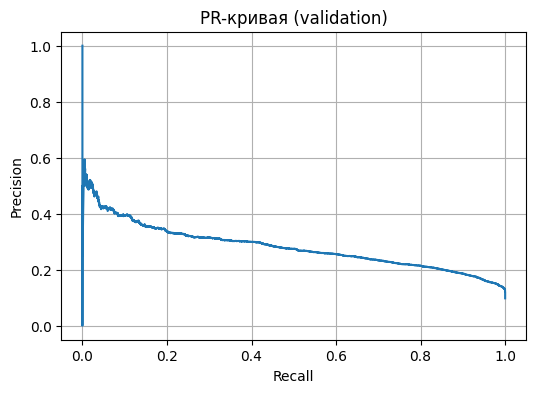

In [77]:


prec, rec, thr = precision_recall_curve(y_val, y_pred_val)
plt.figure(figsize=(6,4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR-кривая (validation)")
plt.grid(True)
plt.show()

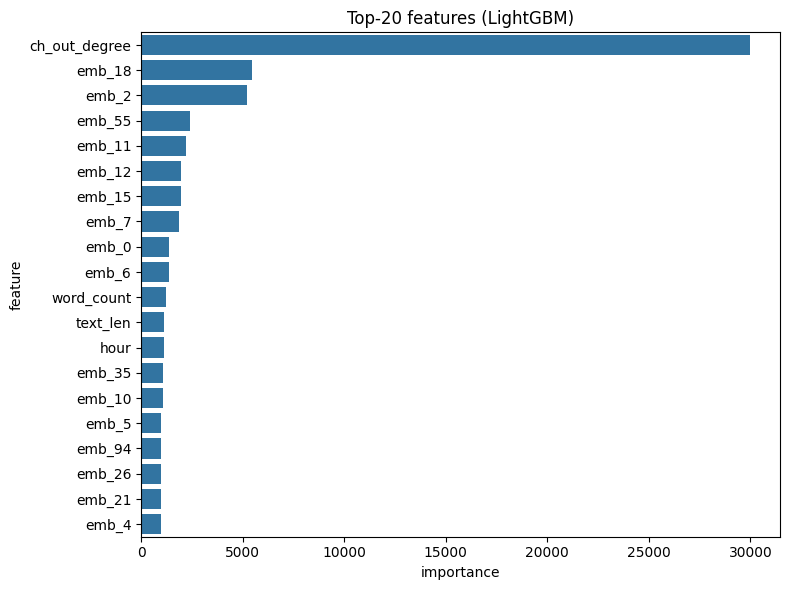

In [85]:
importances = pd.DataFrame({
    "feature": base_cols + graph_cols + emb_cols,
    "importance": model.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importances.head(20), x="importance", y="feature")
plt.title("Top-20 features (LightGBM)")
plt.tight_layout()
plt.show()

In [87]:
def precision_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
    """
    Precision@K: доля положительных среди top-K прогнозов.
    """
    if k <= 0:
        raise ValueError("k must be positive")

    k = min(k, len(y_true))
    top_k_idx = np.argsort(y_pred)[-k:][::-1]
    return y_true[top_k_idx].sum() / k

In [88]:
def recall_at_k(y_true: np.ndarray, y_pred: np.ndarray, k: int) -> float:
    """
    Recall@K: доля найденных положительных среди всех положительных.
    """
    if k <= 0:
        raise ValueError("k must be positive")

    k = min(k, len(y_true))
    top_k_idx = np.argsort(y_pred)[-k:][::-1]

    total_positive = y_true.sum()
    if total_positive == 0:
        return 0.0

    return y_true[top_k_idx].sum() / total_positive

In [90]:
k_values = [50, 100, 200]

print("=== Validation metrics @K ===")
for k in k_values:
    p_k = precision_at_k(y_val, y_pred_val, k)
    r_k = recall_at_k(y_val, y_pred_val, k)
    print(f"K={k:3d} | Precision@K={p_k:.4f} | Recall@K={r_k:.4f}")

=== Validation metrics @K ===
K= 50 | Precision@K=0.5200 | Recall@K=0.0072
K=100 | Precision@K=0.5000 | Recall@K=0.0139
K=200 | Precision@K=0.4800 | Recall@K=0.0267


## Визуализация графа

In [ ]:
ART_DIR = str(ROOT / "artifacts")  # поменяй при необходимости

edges_ch = pd.read_csv(f"{ART_DIR}/edges_ch_msg.csv")
edges_mm = pd.read_csv(f"{ART_DIR}/edges_msg_msg.csv")

edges_ch.head(), edges_mm.head()


Nodes: 392 Edges: 3716


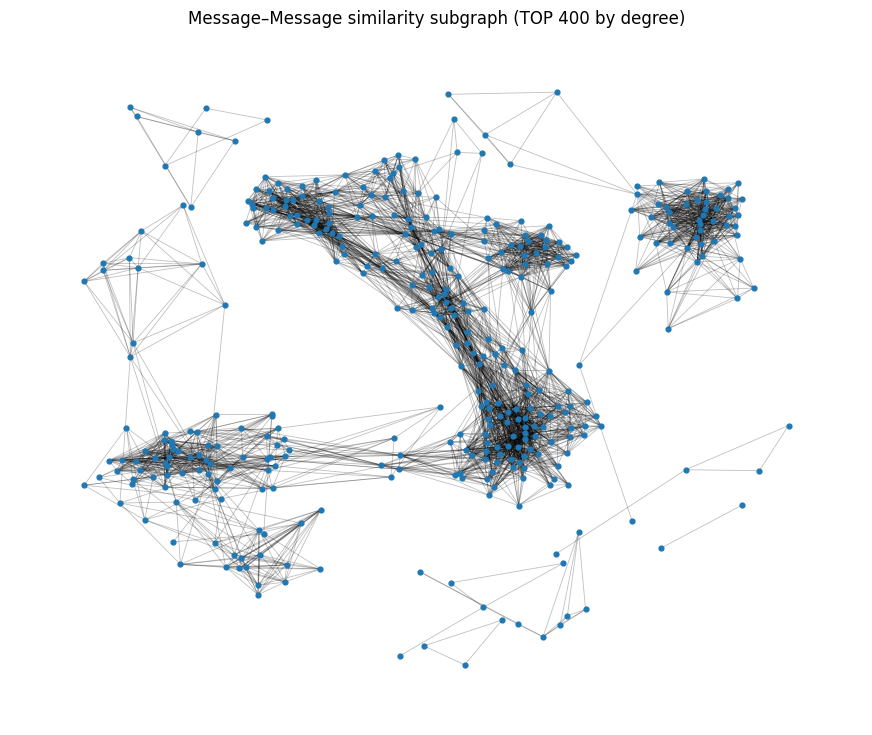

In [96]:
# считаем степень по similarity-графу
deg = pd.concat([edges_mm["src"], edges_mm["dst"]]).value_counts()
TOP_N = 400  # 200–800 обычно ок

top_nodes = deg.head(TOP_N).index.astype(str)

sub_edges = edges_mm[
    edges_mm["src"].astype(str).isin(top_nodes) &
    edges_mm["dst"].astype(str).isin(top_nodes)
].copy()

G = nx.Graph()
G.add_edges_from(sub_edges[["src","dst"]].astype(str).itertuples(index=False, name=None))

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

plt.figure(figsize=(11, 9))
pos = nx.spring_layout(G, seed=42, k=0.25)  # можно менять k
nx.draw_networkx_nodes(G, pos, node_size=12)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6)
plt.title(f"Message–Message similarity subgraph (TOP {TOP_N} by degree)")
plt.axis("off")
plt.show()


Nodes: 392 Edges: 3716


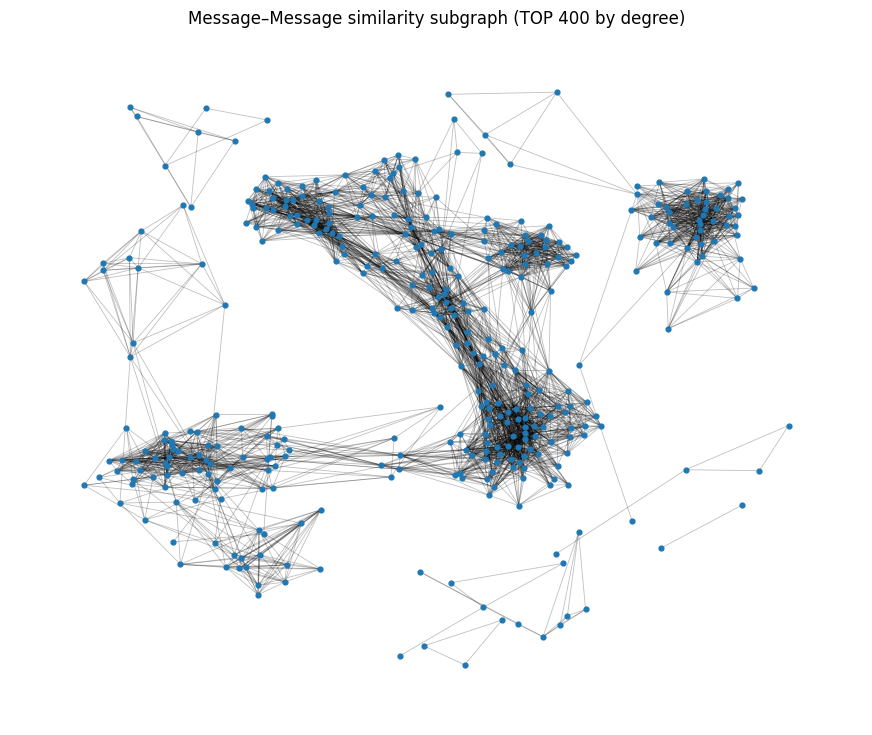

In [ ]:
deg = pd.concat([edges_mm["src"], edges_mm["dst"]]).value_counts()
TOP_N = 400  

top_nodes = deg.head(TOP_N).index.astype(str)

sub_edges = edges_mm[
    edges_mm["src"].astype(str).isin(top_nodes) &
    edges_mm["dst"].astype(str).isin(top_nodes)
].copy()

G = nx.Graph()
G.add_edges_from(sub_edges[["src","dst"]].astype(str).itertuples(index=False, name=None))

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

plt.figure(figsize=(11, 9))
pos = nx.spring_layout(G, seed=42, k=0.25)  # можно менять k
nx.draw_networkx_nodes(G, pos, node_size=12)
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6)
plt.title(f"Message–Message similarity subgraph (TOP {TOP_N} by degree)")
plt.axis("off")
plt.show()

Nodes: 287 Edges: 280


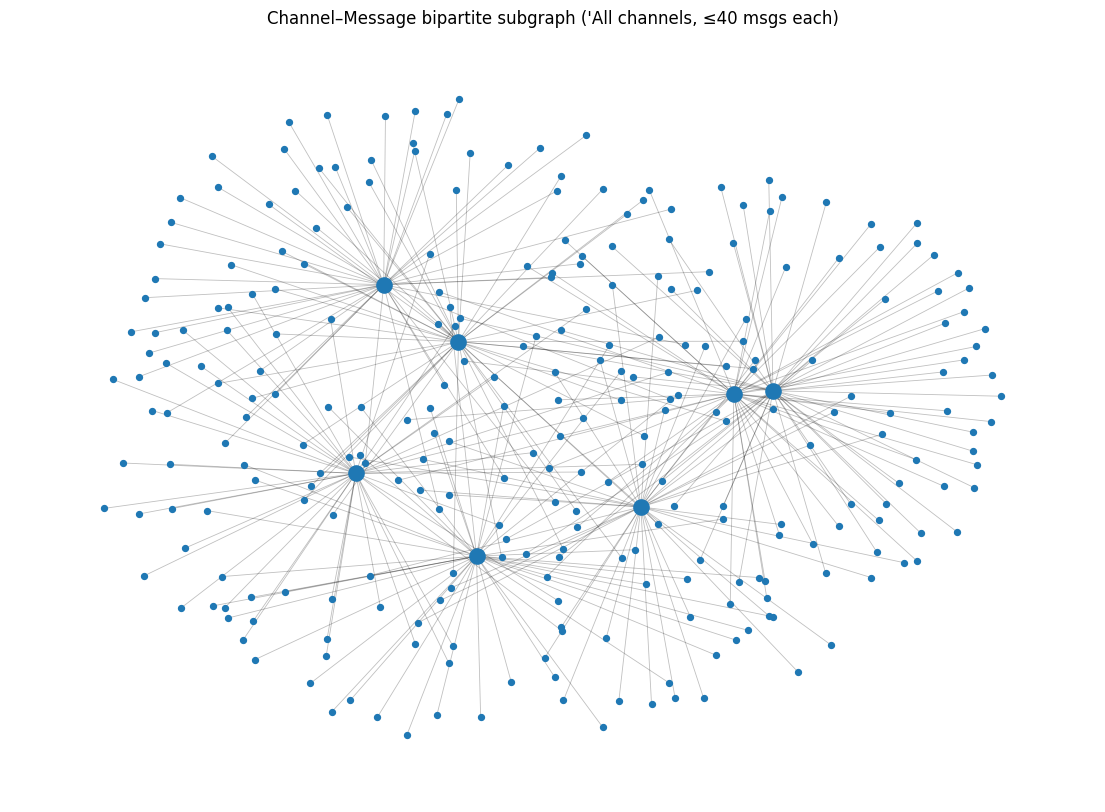

In [100]:
# топ каналов по числу публикаций
ch_counts = edges_ch["src"].value_counts()
TOP_CH = 20
top_channels = ch_counts.head(TOP_CH).index.astype(str)

sub_ch = edges_ch[edges_ch["src"].astype(str).isin(top_channels)].copy()

# ограничим число сообщений на канал, чтобы картинка была читаемой
MAX_MSG_PER_CH = 40
sub_ch = (sub_ch
          .sort_values("t")
          .groupby("src", as_index=False)
          .head(MAX_MSG_PER_CH))

B = nx.Graph()

# добавим узлы с типами
for ch in top_channels:
    B.add_node(f"ch:{ch}", bipartite=0)

for row in sub_ch.itertuples(index=False):
    ch = f"ch:{str(row.src)}"
    m  = f"m:{str(row.dst)}"
    B.add_node(m, bipartite=1)
    B.add_edge(ch, m)

print("Nodes:", B.number_of_nodes(), "Edges:", B.number_of_edges())

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(B, seed=42, k=0.35)
nx.draw_networkx_nodes(B, pos, nodelist=[n for n,d in B.nodes(data=True) if d.get("bipartite")==0], node_size=120)
nx.draw_networkx_nodes(B, pos, nodelist=[n for n,d in B.nodes(data=True) if d.get("bipartite")==1], node_size=18)
nx.draw_networkx_edges(B, pos, alpha=0.25, width=0.6)
plt.title(f"Channel–Message bipartite subgraph ('All channels, ≤{MAX_MSG_PER_CH} msgs each)")
plt.axis("off")
plt.show()